# Do Published Stock-Market Anomalies Keep Working?

**Research question:** once an equity-return anomaly is documented in the academic literature, does it keep working *after the sample period the original authors studied* — or does the predictability fade once the pattern is public?

This notebook is a hands-on replication of the McLean & Pontiff (2016) result — *"Does Academic Research Destroy Stock Return Predictability?"* — extended across the broad anomaly literature. Using the [Open Source Asset Pricing](https://www.openassetpricing.com/) (OSAP) dataset of Chen & Zimmermann, I take a high-quality set of published anomalies, split each one at the end of its *original* study sample, and compare in-sample vs. out-of-sample performance.

**Headline finding.** Across **138** published anomalies, **77% decayed** out-of-sample. Of the **70** that were statistically significant in-sample, only **16** remained significant out-of-sample (t > 2), and just **5** cleared a strict t > 3 bar.

### Key methodological choice: where we split

Each signal is split at its own **`SampleEndYear`**, the last year of data the original authors used and not at the publication year. Returns *after the study's data ends* are the true out-of-sample test: they are the returns nobody had seen when the anomaly was documented. Publication typically lags the sample end by a few years, so splitting at the publication date would throw away genuinely out-of-sample months (often exactly where decay begins).

### Method in brief

1. **(a)** Select high-quality, clearly-predictive signals from the OSAP documentation.
2. **(b)** Download value-weighted decile portfolio returns and reconcile what came back.
3. **(c)** Isolate each signal's long-short (top-minus-bottom decile) series.
4. **(d)** Join the sample-period metadata (`SampleEndYear`) onto the returns.
5. **(e)** For each signal, split at its `SampleEndYear` and compute in- vs. out-of-sample mean return, Sharpe, and Newey-West t-stat.
6. **(f)** Aggregate: how many decayed, and how many stayed significant?
7. **(g)** Visualize the results.

## Setup

Install the OSAP client and import the libraries used throughout.

In [1]:
# Install the Open Source Asset Pricing (OSAP) client, then import the
# libraries used below. Note: `web` (pandas_datareader) is imported to match
# the original environment but is not used in the final analysis.
!pip install openassetpricing

import openassetpricing
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.5 MB/s eta 0:00:00


In [2]:
# Instantiate the OSAP client and inspect its methods; the analysis relies on
# `dl_signal_doc` (the documentation table) and `dl_port` (portfolio returns).
dir(openassetpricing)
op = openassetpricing.OpenAP()

### The OSAP signal documentation

The documentation table has one row per published anomaly, with the metadata the split depends on — publication `Year`, `SampleEndYear`, the reported `T-Stat`, and OSAP's quality/predictability flags.

In [3]:
# Download the signal documentation: one row per published anomaly, carrying
# the author, publication year, sample-end year, and the original t-stat.
docs = op.dl_signal_doc('pandas')
docs.head()

,Acronym,Cat.Signal,Predictability in OP,Signal Rep Quality,Authors,Year,LongDescription,Journal,Cat.Form,Cat.Data,...,T-Stat,Stock Weight,LS Quantile,Quantile Filter,Portfolio Period,Start Month,Filter,Notes,Detailed Definition,GScholarCites202509
0,AbnormalAccruals,Predictor,1_clear,2_fair,Xie,2001,Abnormal Accruals,AR,continuous,Accounting,...,8.43,EW,0.10,None,12.0,6.0,None,OP is aggressive and lags accounting data by o...,Define Accruals as net income (ib) minus opera...,139.0
1,Accruals,Predictor,1_clear,1_good,Sloan,1996,Accruals,AR,continuous,Accounting,...,4.71,EW,0.10,None,12.0,6.0,abs(prc)>5,Table 6 year t+1 hedge. Only size adjusted an...,Annual change in current total assets (act) mi...,56.0
2,AccrualsBM,Predictor,1_clear,1_good,Bartov and Kim,2004,Book-to-market and accruals,RFQA,discrete,Accounting,...,5.50,EW,0.20,None,12.0,6.0,None,None,Binary variable equal to 1 if stock is in the ...,22.0
3,Activism1,Predictor,1_clear,1_good,Cremers and Nair,2005,Takeover vulnerability,JF,continuous,13F,...,3.13,VW,0.25,None,1.0,6.0,None,works a bit better EW in Tab 3,24 minus Governance Index (G). Set to missing ...,2036.0
4,AM,Predictor,1_clear,1_good,Fama and French,1992,Total assets to market,JF,continuous,Accounting,...,5.69,EW,NaN,None,12.0,6.0,None,None,Total assets (at) divided by market value of e...,29625.0


## (a) Select high-quality signals

Restrict the universe to anomalies OSAP flags as *clearly predictive* with *good* or *fair* replication quality, and that carry both a sample-end year and a publication year (both are needed for the split). This filter yields **162** documented signals.

In [4]:
# Keep only high-quality, clearly-predictive signals that also have the
# metadata the split needs: OSAP flags the signal as clearly predictive, its
# replication quality is good or fair, and both the sample-end year and the
# publication year are present.
good = docs[
    (docs['Predictability in OP'] == '1_clear') &
    (docs['Signal Rep Quality'].isin(['1_good', '2_fair'])) &
    (docs['SampleEndYear'].notna()) &
    (docs['Year'].notna())
].copy()

print('Signals passing the filter:', len(good))
print(good[['Acronym', 'Authors', 'Year', 'SampleEndYear', 'T-Stat']].head(20))

Signals passing the filter: 162
               Acronym                         Authors  Year  SampleEndYear  \
0     AbnormalAccruals                             Xie  2001           1992   
1             Accruals                           Sloan  1996           1991   
2           AccrualsBM                  Bartov and Kim  2004           1998   
3            Activism1                Cremers and Nair  2005           2001   
4                   AM                 Fama and French  1992           1990   
5      AnalystRevision     Hawkins, Chamberlin, Daniel  1984           1980   
6   AnnouncementReturn  Chan, Jegadeesh and Lakonishok  1996           1992   
7          AssetGrowth        Cooper, Gulen and Schill  2008           2003   
8      BetaLiquidityPS            Pastor and Stambaugh  2003           1999   
9         BetaTailRisk                 Kelly and Jiang  2014           2010   
10             betaVIX                      Ang et al.  2006           2000   
11                  

## (b) Download portfolio returns and reconcile

Pull value-weighted decile portfolio returns (`deciles_vw`) for the selected signals. Not every documented predictor has a downloadable portfolio in OSAP, so we first run a small **test pull on 3 signals**, then the full pull, and **reconcile** requested vs. received. Of the 162 requested, 24 have no value-weighted decile portfolio and drop out, leaving **138** signals with return data.

In [5]:
signal_list = good['Acronym'].tolist()

# Test on just the first 3 signals to confirm the mechanism before scaling up.
test_signals = signal_list[:3]
print('Testing with:', test_signals)

test_pull = op.dl_port('deciles_vw', 'pandas', test_signals)

# Did we get all 3 back, and does the table include the long-short ('LS') row?
print(test_pull['signalname'].unique())
print(test_pull['port'].unique())

Testing with: ['AbnormalAccruals', 'Accruals', 'AccrualsBM']
One or more input predictors are not available.

Data is downloaded: 7s
['AbnormalAccruals' 'Accruals']
['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' 'LS']


In [6]:
requested = set(test_signals)
received = set(test_pull['signalname'].unique())

# Set difference: signals we asked for but did not get back.
dropped = requested - received
print('Requested:', len(requested))
print('Received :', len(received))
print('Dropped  :', dropped)

Requested: 3
Received : 2
Dropped  : {'AccrualsBM'}


In [7]:
# The full pull: request all 162 filtered signals at once. Not every predictor
# has a downloadable value-weighted decile portfolio in OSAP, so 24 drop out
# and 138 signals come back with return data.
full_pull = op.dl_port('deciles_vw', 'pandas', signal_list)

# Reconcile: what did we actually get back?
requested = set(signal_list)
received = set(full_pull['signalname'].unique())
dropped = requested - received

print('Requested:', len(requested))
print('Received :', len(received))
print('Dropped  :', len(dropped))
print('Dropped signals:', sorted(dropped))
dropped_signals = sorted(dropped)

One or more input predictors are not available.

Data is downloaded: 4s
Requested: 162
Received : 138
Dropped  : 24
Dropped signals: ['AccrualsBM', 'ChForecastAccrual', 'ChNAnalyst', 'CitationsRD', 'ConvDebt', 'DivInit', 'DivOmit', 'DivSeason', 'DivYieldST', 'ExchSwitch', 'Governance', 'IndIPO', 'MS', 'MomRev', 'MomVol', 'OScore', 'PatentsRD', 'RDIPO', 'RIO_Disp', 'RIO_MB', 'RIO_Turnover', 'RIO_Volatility', 'ShareVol', 'SurpriseRD']


## (c) Isolate the long-short series

Each signal's table contains all ten deciles plus the pre-computed long-short (`LS`) row — the top decile minus the bottom decile. The decay test only needs that hedged `LS` series, so we keep those rows and check how many monthly observations each signal has.

In [8]:
# Keep only the long-short rows (top decile minus bottom decile) across all
# signals -- that hedged series is what the decay test measures.
ls_all = full_pull[full_pull['port'] == 'LS'].copy()

# How many monthly long-short observations does each signal have?
obs_per_signal = ls_all.groupby('signalname').size().sort_values()

print('Signals with LS data:', obs_per_signal.shape[0])
print('\nShortest 10:')
print(obs_per_signal.head(10))
print('\nLongest 10:')
print(obs_per_signal.tail(10))

Signals with LS data: 138

Shortest 10:
signalname
Activism1         197
dVolCall          323
dCPVolSpread      323
CPVolSpread       324
RIVolSpread       324
SmileSlope        324
OptionVolume1     331
PctTotAcc         438
betaVIX           467
EarningsStreak    482
dtype: int64

Longest 10:
signalname
Size               1182
IndMom             1182
DolVol             1185
TrendFactor        1186
Mom12mOffSeason    1186
IndRetBig          1187
ReturnSkew         1187
MaxRet             1187
STreversal         1187
Price              1188
dtype: int64


## (d) Join the sample-period metadata

The returns carry no sample-period information, so we join `SampleEndYear` (plus `Year` and `T-Stat`) from the documentation onto every return row, then verify that every signal matched.

In [9]:
# 1. Take just the columns we need from docs and rename Acronym -> signalname
#    so it matches the returns table's key.
meta = docs[['Acronym', 'Year', 'SampleEndYear', 'T-Stat']].copy()
meta = meta.rename(columns={'Acronym': 'signalname'})

# 2. Merge the metadata onto every return row, matching on signalname.
ls_all = ls_all.merge(meta, on='signalname', how='left')

# 3. Verify the join worked -- did every row get a SampleEndYear?
print('Total rows          :', len(ls_all))
print('Rows missing EndYear :', ls_all['SampleEndYear'].isna().sum())
print('Signals missing meta :', sorted(ls_all[ls_all['SampleEndYear'].isna()]['signalname'].unique()))
ls_all.head()

Total rows          : 116562
Rows missing EndYear : 0
Signals missing meta : []


,signalname,port,date,ret,signallag,Nlong,Nshort,Year,SampleEndYear,T-Stat
0,AM,LS,1951-07-31,2.086206,NaN,34,34,1992,1990,5.69
1,AM,LS,1951-08-31,2.936486,NaN,34,34,1992,1990,5.69
2,AM,LS,1951-09-28,2.515863,NaN,34,34,1992,1990,5.69
3,AM,LS,1951-10-31,3.344928,NaN,34,34,1992,1990,5.69
4,AM,LS,1951-11-30,2.517470,NaN,34,34,1992,1990,5.69


## (e) Per-signal decay loop

This is the core of the analysis. For each signal we split its long-short series at its **own** `SampleEndYear` into an *in-sample* period (dates on or before the split) and an *out-of-sample* period (everything after).

**Why split at `SampleEndYear` rather than the publication year?** The months right after the original data ends are the first truly out-of-sample observations — returns that did not exist when the authors formed the anomaly. Splitting at publication instead would discard the several years between sample-end and publication, which are themselves out-of-sample and often where decay begins.

For each side we compute the annualized mean return, the annualized Sharpe ratio, and a **Newey-West t-stat with 6 lags** (to account for autocorrelation in monthly returns). Signals with fewer than 12 months on either side are skipped. The result is the `decay` table, one row per signal, with `ret_decay = ret_out - ret_in` (negative means the anomaly weakened).

In [10]:
def nw_tstat(r_decimal, lags=6):
    """Newey-West t-stat for the mean of an already-decimal return series.

    Regresses the returns on a constant using HAC (Newey-West) standard errors
    with `lags` lags, and returns the t-stat on the estimated mean.
    """
    r = r_decimal.dropna()
    if len(r) < 12:  # too few observations to trust the estimate
        return np.nan
    X = np.ones(len(r))
    res = sm.OLS(r.values, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return res.tvalues[0]


results = []

# For each signal, split its own long-short series at the end of the ORIGINAL
# study's sample and compare performance before vs. after that date.
for name, g in ls_all.groupby('signalname'):
    end_year = g['SampleEndYear'].iloc[0]  # this signal's own split year
    split_date = pd.to_datetime(f'{int(end_year)}-12-31')

    # Percent -> decimal, indexed by date and sorted into time order.
    r = g.set_index('date')['ret'].sort_index() / 100

    in_s = r[r.index <= split_date]   # in-sample: through the original sample end
    out_s = r[r.index > split_date]   # out-of-sample: everything after

    # Require at least 12 months on BOTH sides for the comparison to mean anything.
    if len(in_s) < 12 or len(out_s) < 12:
        continue

    results.append({
        'signal': name,
        'SampleEndYear': int(end_year),
        'n_in': len(in_s),
        'n_out': len(out_s),
        'ret_in': in_s.mean() * 12,      # annualized mean return, in-sample
        'ret_out': out_s.mean() * 12,    # annualized mean return, out-of-sample
        'sharpe_in': (in_s.mean() * 12) / (in_s.std() * np.sqrt(12)),    # annualized Sharpe
        'sharpe_out': (out_s.mean() * 12) / (out_s.std() * np.sqrt(12)),
        't_in': nw_tstat(in_s),          # Newey-West t-stat (6 lags), in-sample
        't_out': nw_tstat(out_s),        # Newey-West t-stat (6 lags), out-of-sample
    })

decay = pd.DataFrame(results)
decay['ret_decay'] = decay['ret_out'] - decay['ret_in']  # negative => decayed

print('Signals in final table:', len(decay))
decay.head(10)

Signals in final table: 138


,signal,SampleEndYear,n_in,n_out,ret_in,ret_out,sharpe_in,sharpe_out,t_in,t_out,ret_decay
0,AM,1990,474,408,0.024105,0.008057,0.178569,0.036107,1.029403,0.177552,-0.016048
1,AbnormalAccruals,1992,246,384,0.068545,0.018069,0.762637,0.129896,3.241819,0.638992,-0.050476
2,Accruals,1991,474,396,0.067129,0.018942,0.595881,0.167055,3.786611,0.960709,-0.048187
3,Activism1,2001,135,62,0.044309,-0.036739,0.392610,-0.386160,1.850305,-1.330600,-0.081048
4,AnalystRevision,1980,58,528,0.073565,0.053259,0.815948,0.434534,1.381206,3.029516,-0.020307
5,AnnouncementReturn,1992,256,384,0.160685,0.117468,1.636345,0.869772,8.227618,5.054445,-0.043217
6,AssetGrowth,2003,618,252,0.063022,0.000358,0.458271,0.002722,3.047805,0.010684,-0.062664
7,BM,1976,306,576,0.059747,0.055764,0.427727,0.344554,2.077432,2.046929,-0.003983
8,BMdec,1990,462,408,0.065204,-0.019496,0.447467,-0.139753,2.670099,-0.700227,-0.084700
9,BPEBM,2001,474,276,0.019125,0.011895,0.259649,0.124976,1.766975,0.690923,-0.007230


## (f) The aggregate finding

The headline numbers: how many signals decayed, the median decay, and how many stayed statistically significant out-of-sample at the t > 2 and t > 3 bars.

In [11]:
# Headline counts: how many signals decayed, the median decay, and how many
# stayed statistically significant out-of-sample at the t > 2 and t > 3 bars.
print('Signals total          :', len(decay))
print('Signals that decayed   :', (decay['ret_decay'] < 0).sum())
print('Median return decay    :', decay['ret_decay'].median())
print('Significant in-sample  (t_in > 2):', (decay['t_in'] > 2).sum())          # 70
print('SURVIVED (t_in>2 AND t_out>2):', ((decay['t_in']>2) & (decay['t_out']>2)).sum())  # 16
print('SURVIVED strict (t_in>2 AND t_out>3):', ((decay['t_in']>2) & (decay['t_out']>3)).sum())  # 5

Signals total          : 138
Signals that decayed   : 106
Median return decay    : -0.02821117042673737
Significant in-sample  (t_in > 2): 70
SURVIVED (t_in>2 AND t_out>2): 16
SURVIVED strict (t_in>2 AND t_out>3): 5


## (g) Visualizing the decay

Two views of the result: a scatter of in-sample vs. out-of-sample t-stats (points below the diagonal decayed; the dotted lines mark the t = 2 and t = 3 bars), and a histogram of the change in annualized long-short return.

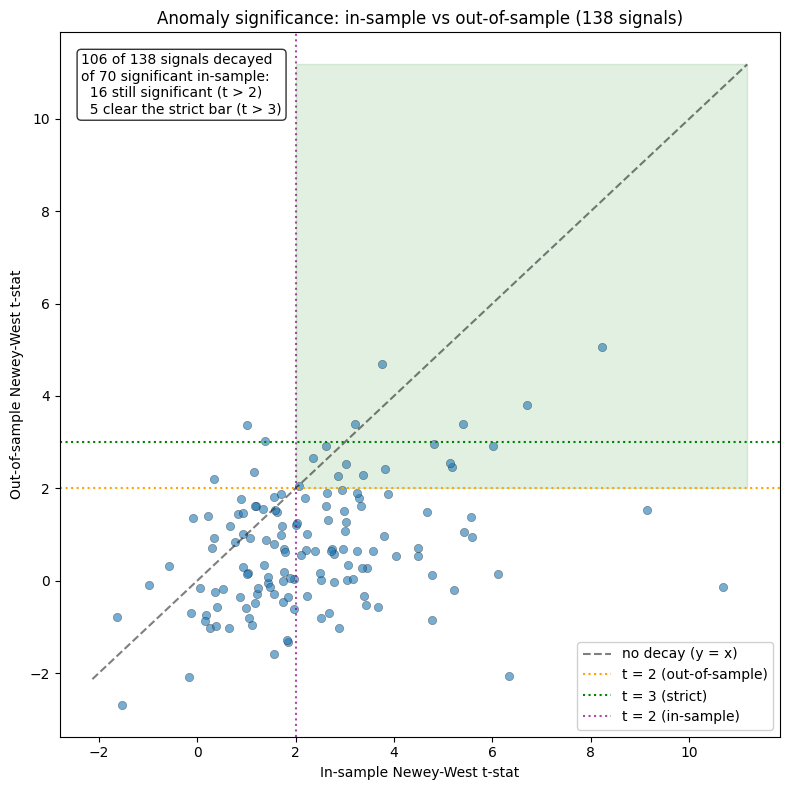

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

# Each point is one anomaly: in-sample t-stat (x) vs. out-of-sample t-stat (y).
ax.scatter(decay['t_in'], decay['t_out'],
           alpha=0.6, edgecolor='k', linewidth=0.3)

# Diagonal y = x: points ON the line held up; points BELOW it decayed.
lim = [decay['t_in'].min() - 0.5, decay['t_in'].max() + 0.5]
ax.plot(lim, lim, 'k--', alpha=0.5, label='no decay (y = x)')

# Significance reference lines.
ax.axhline(2, color='orange', ls=':', label='t = 2 (out-of-sample)')
ax.axhline(3, color='green', ls=':', label='t = 3 (strict)')
ax.axvline(2, color='purple', ls=':', alpha=0.7, label='t = 2 (in-sample)')
ax.fill_between([2, lim[1]], 2, lim[1], alpha=0.06, color='green', zorder=0)  # survivor quadrant: t>2 on BOTH axes

# optional: lightly shade the "survivor" quadrant (sig in AND out at t>2)
ax.fill_between([2, lim[1]], 2, lim[1], alpha=0.06, color='green', zorder=0) # subtle

# Summary counts, computed from the same `decay` table used above.
# Summary counts, conditioned on being significant in-sample.
n_decayed = (decay['ret_decay'] < 0).sum()
n_sig_in  = (decay['t_in'] > 2).sum()                                # 70
n_surv2   = ((decay['t_in'] > 2) & (decay['t_out'] > 2)).sum()       # 16 — survived
n_surv3   = ((decay['t_in'] > 2) & (decay['t_out'] > 3)).sum()       # 5  — survived strict

annotation = (
    f'{n_decayed} of {len(decay)} signals decayed\n'
    f'of {n_sig_in} significant in-sample:\n'
    f'  {n_surv2} still significant (t > 2)\n'
    f'  {n_surv3} clear the strict bar (t > 3)'
)

ax.text(0.03, 0.97, annotation, transform=ax.transAxes,
        va='top', ha='left', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('In-sample Newey-West t-stat')
ax.set_ylabel('Out-of-sample Newey-West t-stat')
ax.set_title('Anomaly significance: in-sample vs out-of-sample (138 signals)')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('chart1_tstat_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

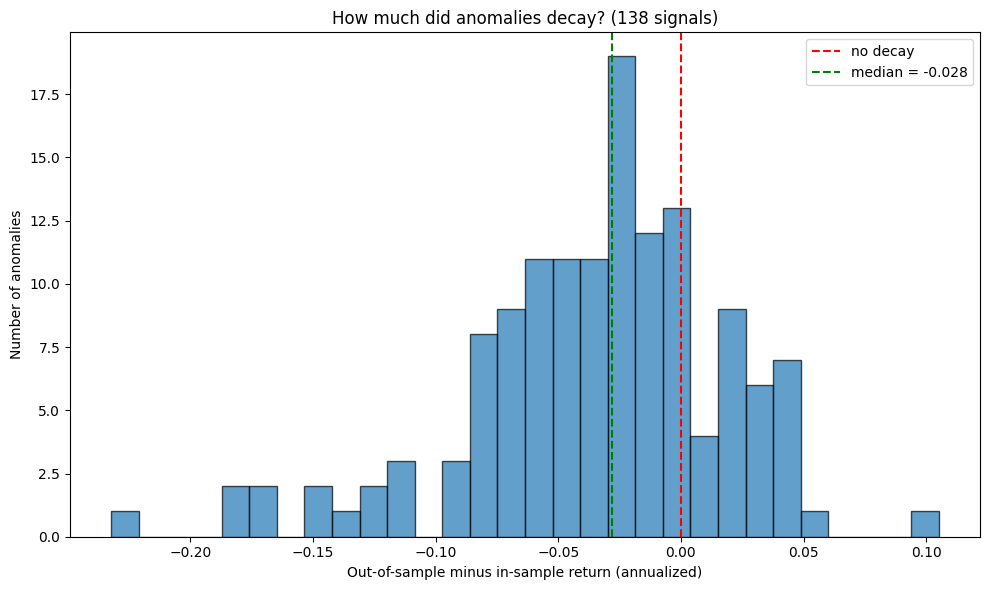

In [13]:
fig2, ax = plt.subplots(figsize=(10, 6))

# Distribution of the change in annualized long-short return (out minus in).
ax.hist(decay['ret_decay'], bins=30, edgecolor='k', alpha=0.7)
ax.axvline(0, color='red', ls='--', label='no decay')
ax.axvline(decay['ret_decay'].median(), color='green', ls='--',
           label=f"median = {decay['ret_decay'].median():.3f}")

ax.set_xlabel('Out-of-sample minus in-sample return (annualized)')
ax.set_ylabel('Number of anomalies')
ax.set_title('How much did anomalies decay? (138 signals)')
ax.legend()
plt.tight_layout()
plt.savefig('chart2_decay_hist.png', dpi=150, bbox_inches='tight')
plt.show()

## Export the results

Save the per-signal `decay` table to CSV for the repository.

In [14]:
# Save the per-signal results for the repo.
decay.to_csv('decay_results.csv', index=False)
print('saved', len(decay), 'rows')

saved 138 rows


## Conclusion

Across 138 high-quality published anomalies, split at each signal's own SampleEndYear:

106 of 138 (77%) decayed out-of-sample. Their annualized long-short return was lower after the original sample ended than during it.
The median anomaly lost about 2.8 percentage points of annualized return (median ret_decay = −0.028).
Statistical significance collapses: of the 70 anomalies clearing a t > 2 Newey-West bar in-sample, only 16 still clear it out-of-sample, and just 5 clear a strict t > 3.
This is exactly the pattern McLean & Pontiff (2016) documented and attributed to the anomaly becoming public: once a predictable pattern is published, arbitrage capital and awareness erode it. Out-of-sample, the returns nobody had seen when the paper was written. is where anomalies go to fade.

The practical takeaway for anyone building strategies on the anomaly literature: an impressive in-sample t-stat is a weak promise about the future. A handful of effects do survive at a strict bar, but the base rate of persistence is low, and a published edge should be treated as an upper bound on what remains.

Caveats
Standardized construction (uniform VW deciles) may account for some measured decay.
In-sample is an OSAP reconstruction, not the authors' exact sample.
Split at sample-end, by design (counts data-end → publication years as out-of-sample).